# Data project


**Table of contents**<a id='toc0_'></a>
- 1. [Inequality in Denmark](#toc1_)
  - 1.1. [The Gini coefficient and the top 10 percent share](#toc1_1_)
  - 1.2. [Prediction](#toc1_2_)
  - 1.3. [Municipalities](#toc1_3_)
  - 1.4. [Extension](#toc1_4_)
- 2. [Simulating the income distribution](#toc0_)
  - 2.1. [The model](#toc2_1_)
  - 2.2. [Simulate the income distribution](#toc2_2_)
  - 2.3. [Compute the Gini coefficient](#toc2_3_)
  - 2.4. [What drives inequality?](#toc2_4_)
  - 2.5. [Extension: more risk](#toc2_5_)

## 1. <a id='toc1_'></a>[Inequality in Denmark](#toc1_)

### 1.1. <a id='toc1_1_'></a>[The Gini coefficient and the top 10 percent share](#toc0_)

#### 1.1.1. <a id='toc1_1_'></a>[Gini coefficient for Denmark over time](#toc0_)

test

First, we import relevant packages and data from dst:

In [1]:
#%pip install git+https://github.com/alemartinello/dstapi

import numpy as np
import pandas as pd

# APIs
#from dstapi import DstApi

# plotting
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

from scipy.optimize import minimize

from scipy.stats import linregress

# Load data from dst:
from dstapi import DstApi

We load the data on Gini coefficient:

In [2]:
IFOR41 = DstApi('IFOR41') 

Information about the variables:

In [3]:
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


We see that All Denmark = 000 and ULLIG=70. We use this to extract the relevant data:

In [4]:
# Set the parameters for the data we want to download
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},       # Gini coefficient
        {'code': 'KOMMUNEDK', 'values': ['000']},  # All Denmark
        {'code': 'Tid', 'values': ['*']}           # all years
    ]
}

# Download the data into a dataFrame
Gini = IFOR41.get_data(params=params)

# Set the correct data types and sort the observations by year
Gini['TID'] = Gini['TID'].astype(int)
Gini['INDHOLD'] = Gini['INDHOLD'].astype(float)
Gini = Gini.set_index('TID').sort_index()

# Display
display(Gini.head(5))

,ULLIG,KOMMUNEDK,INDHOLD
TID,,,
1987,Gini coefficient,All Denmark,22.07
1988,Gini coefficient,All Denmark,22.06
1989,Gini coefficient,All Denmark,21.93
1990,Gini coefficient,All Denmark,22.16
1991,Gini coefficient,All Denmark,21.99


We plot the Gini coefficient from 1987-2024: 

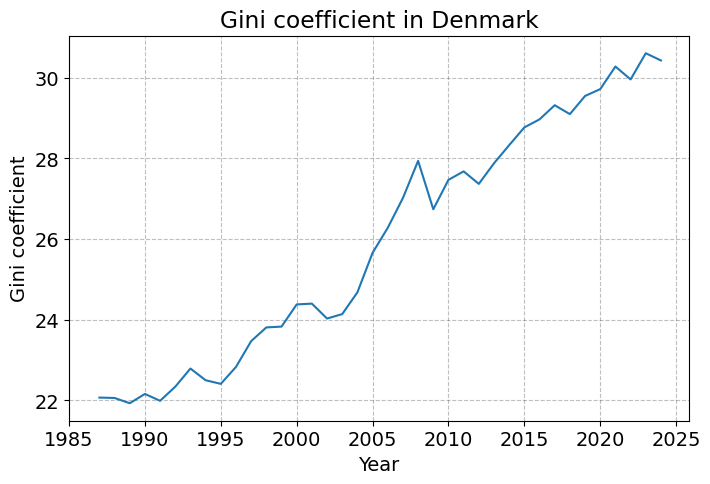

1987: 22.070
2024: 30.430
Increase: 8.360 percentage points


In [5]:
# Plot
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

ax.plot(Gini.index, Gini['INDHOLD'])

ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

ax.set_xticks(list(range(1985, 2025, 5)) + [2025])

plt.show()

# Change in Gini
increase = Gini.loc[2024, 'INDHOLD'] - Gini.loc[1987, 'INDHOLD']
print(f"1987: {Gini.loc[1987, 'INDHOLD']:.3f}")
print(f"2024: {Gini.loc[2024, 'INDHOLD']:.3f}")
print(f"Increase: {increase:.3f} percentage points")      

We see that the Gini coefficient has been rising over the period, from 22% in 1987 to 30% in 2024, corresponding to an increase of 8 percentage points. We see the largest decrease in the Gini coefficient in 2009, following the financial crisis.

#### 1.1.2. <a id='toc1_1_'></a>[Define the share of total income going to the richest 10 percent](#toc0_)

We add data on income across the different decile groups.

In [18]:
# Load data
IFOR32 = DstApi('IFOR32')

# Check the variables and their values
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


We extract the relevant variables:

In [19]:
# Set download parameters
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},       # All 10 income deciles
        {'code': 'KOMMUNEDK', 'values': ['000']},    # All Denmark
        {'code': 'Tid', 'values': ['*']}             # All years
    ]
}

# Download the data
Deciles = IFOR32.get_data(params=params)

# Set types
Deciles['TID'] = Deciles['TID'].astype(int)
Deciles['INDHOLD'] = Deciles['INDHOLD'].astype(float)

# Sort data
order = ['First decil', 'Second decil', 'Third decil', 'Fourth decil', 'Fifth decil', 'Sixth decil', 'Seventh decil', 'Eigth decil', 'Ninth decil', 'Tenth decil']
Deciles['DECILGEN'] = pd.Categorical(Deciles['DECILGEN'], categories=order, ordered=True)
Deciles = Deciles.sort_values(['TID', 'DECILGEN'])

# Display 
display(Deciles.head(5))

,DECILGEN,KOMMUNEDK,TID,INDHOLD
260,First decil,All Denmark,1987,31418.0
261,Second decil,All Denmark,1987,59014.0
262,Third decil,All Denmark,1987,68786.0
263,Fourth decil,All Denmark,1987,77577.0
264,Fifth decil,All Denmark,1987,85361.0


We calculate the share of total income going to the richest 10 percent (top 10%) by dividing average income of tenth decile by total income of all deciles:

In [20]:
#for each year take the tenth decil income and divide with total income
Top10 = Deciles.groupby('TID').apply(lambda x: x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum())*100

display(Top10.head())

/var/folders/vx/xr1r5zt16cz0d84mb3n5lf2m0000gn/T/ipykernel_67243/2074638898.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Top10 = Deciles.groupby('TID').apply(lambda x: x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum())*100


TID
1987    18.454866
1988    18.428870
1989    18.495170
1990    18.641480
1991    18.668346
dtype: float64

#### 1.1.3. <a id='toc1_1_'></a>[Compare Gini coefficient and top 10%](#toc0_)

We plot Gini coefficient and top 10% in same diagram:

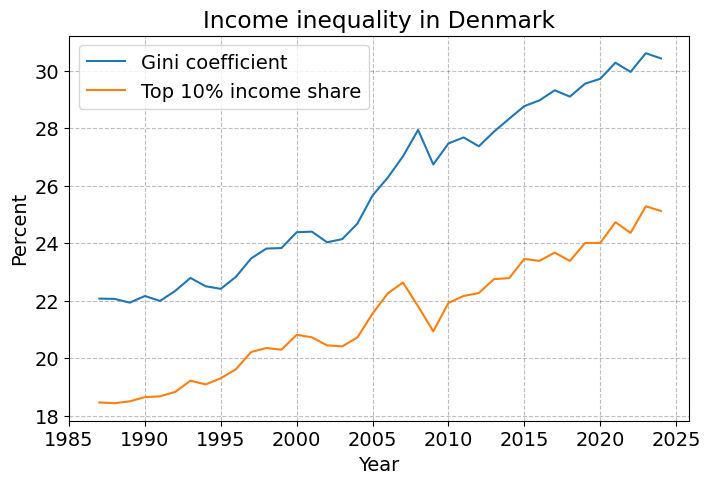

In [25]:
# Combine the Gini coefficient and top 10% income share by year
df = pd.concat([Gini['INDHOLD'].rename('Gini'), Top10.rename('Top 10%')], axis=1)

# Plot both measures over time
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

ax.plot(df.index, df['Gini'], label='Gini coefficient')
ax.plot(df.index, df['Top 10%'], label='Top 10% income share')

ax.set_title('Income inequality in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Percent')
ax.legend()
#ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=12, handlelength=1.5)
ax.set_xticks(list(range(1985, 2025, 5)) + [2025])

plt.show()

We see that both measures show that inequality has risen over the period, with similar fluctuations over time. Thus, the top 10% income share largely captures the overall changes in inequality over time.

We compute the correlation between the two variables:

In [123]:
corr = Gini['INDHOLD'].corr(Top10)
print(corr)

0.981641545052772


Hence, there is a strong positive correlation between the two variables, suggesting that the two measures are closely aligned.

### 1.2. <a id='toc1_1_'></a>[Prediction](#toc0_)

#### 1.2.1. <a id='toc1_1_'></a>[Solve minimization problem](#toc0_)

We solve the minimization problem using scipy.optimize.minimize:

In [26]:
# t is the number of years since 1987
t = Gini.index - 1987
y = Gini['INDHOLD']

# Define the sum of squared errors for a polynomial of degree p
# The function returns the total squared difference between actual and predicted values. This is what we want to minimize
def objective(beta, t, y, p):
    prediction = sum(beta[k] * t**k for k in range(p + 1))
    return np.sum((y - prediction)**2)   

# p = 1: linear trend 
linear = minimize(objective, np.zeros(2), args=(t, y, 1))

# p = 2: quadratic trend
quadratic = minimize(objective, np.zeros(3), args=(t, y, 2))

print("Linear coefficients:", linear.x)
print("Quadratic coefficients:", quadratic.x)

Linear coefficients: [21.04275354  0.26354959]
Quadratic coefficients: [2.13041883e+01 2.19976116e-01 1.17766330e-03]


#### 1.2.2. <a id='toc1_1_'></a>[Compare with np.polyfit](#toc0_)

We check whether our result is similar to the result obtained using the built-in minimizer.

In [27]:
# Check the linear trend
polyfit_linear = np.polyfit(t, y, 1)

# Check the quadratic trend
polyfit_quadratic = np.polyfit(t, y, 2)

print("Linear:")
print("minimize:", linear.x)
print("polyfit:", polyfit_linear[::-1])

print("Quadratic:")
print("minimize:", quadratic.x)
print("polyfit:", polyfit_quadratic[::-1])

Linear:
minimize: [21.04275354  0.26354959]
polyfit: [21.04275304  0.26354962]
Quadratic:
minimize: [2.13041883e+01 2.19976116e-01 1.17766330e-03]
polyfit: [2.13042004e+01 2.19975061e-01 1.17769085e-03]


We see that the results are almost identical. 

#### 1.2.3. <a id='toc1_1_'></a>[Prediction of the Gini coefficient in 2030 and 2040](#toc0_)

We predict the Gini coefficient in 2030 and 2024:

In [29]:
# Prediction years
t_pred = np.array([2030 - 1987, 2040 - 1987])

# Linear predictions
linear_pred = linear.x[0] + linear.x[1] * t_pred

# Quadratic predictions
quadratic_pred = quadratic.x[0] + quadratic.x[1] * t_pred + quadratic.x[2] * t_pred**2

print("Linear predictions:", linear_pred)
print("Quadratic predictions:", quadratic_pred)

Linear predictions: [32.37538612 35.01088207]
Quadratic predictions: [32.94066071 36.27097864]


We plot the predicted values:

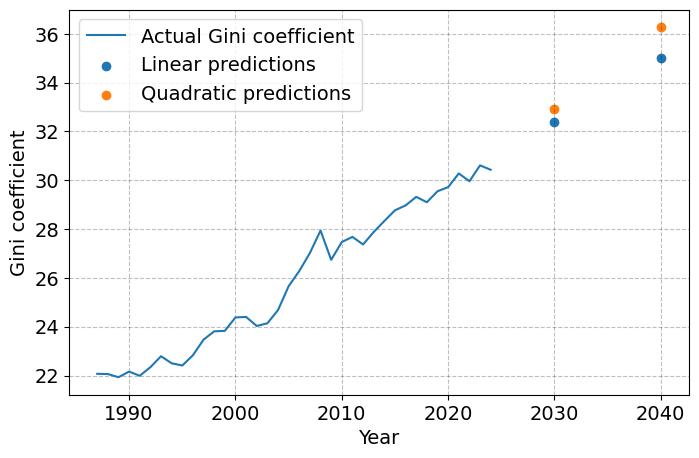

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(Gini.index, y, label='Actual Gini coefficient')

plt.scatter([2030, 2040], linear_pred, label='Linear predictions')
plt.scatter([2030, 2040], quadratic_pred, label='Quadratic predictions')

plt.xlabel('Year')
plt.ylabel('Gini coefficient')
plt.legend()
plt.show()

We find that the quadratic trend predicts a stronger increase in the Gini coefficient over time. However, it is not clear which specification provides the more reliable prediction. Since the Gini coefficient is influenced by many factors, this simple trend model is unlikely to accurately predict future inequality. Past trends may not necessarily be good predictors of future developments.

### 1.3. <a id='toc1_1_'></a>[Municipalities](#toc0_)

#### 1.3.1. <a id='toc1_1_'></a>[Correlation between the Gini coefficient and the top 10 percent share across municipalities](#toc0_)

We import the data again now on the municipality level:

In [44]:
# Set the parameters for the data we want to download
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['1987', '2024']}
    ]
}

# Download the data into a pandas DataFrame
Gini_municipal = IFOR41.get_data(params=params)
Gini_municipal = Gini_municipal[Gini_municipal['KOMMUNEDK'] != 'All Denmark']

# Set the correct data types and sort
Gini_municipal['TID'] = Gini_municipal['TID'].astype(int)
Gini_municipal['INDHOLD'] = Gini_municipal['INDHOLD'].astype(float)

Gini_2024 = Gini_municipal[Gini_municipal['TID'] == 2024][['KOMMUNEDK', 'INDHOLD']]
Gini_1987 = Gini_municipal[Gini_municipal['TID'] == 1987][['KOMMUNEDK', 'INDHOLD']]

# Display
display(Gini_2024.head(5))

,KOMMUNEDK,INDHOLD
100,Copenhagen,34.97
101,Frederiksberg,36.54
102,Ballerup,26.72
103,Brøndby,26.16
104,Dragør,28.86


Likewise for income deciles:

In [43]:
# Set download parameters
params = {
'table': 'IFOR32',
'format': 'BULK',
'lang': 'en',
'variables': [
{'code': 'DECILGEN', 'values': ['*']},       # All 10 income deciles
{'code': 'KOMMUNEDK', 'values': ['*']},      # All municipalities
{'code': 'Tid', 'values': ['1987', '2024']}
]
}

# Download the data
Deciles_municipal = IFOR32.get_data(params=params)
Deciles_municipal = Deciles_municipal[Deciles_municipal['KOMMUNEDK'] != 'All Denmark']

# Set types and sort
Deciles_municipal['TID'] = Deciles_municipal['TID'].astype(int)
Deciles_municipal['INDHOLD'] = Deciles_municipal['INDHOLD'].astype(float)

# Calculate top 10% income share for each municipality and year
Top10_2024 = Deciles_municipal[Deciles_municipal['TID'] == 2024].groupby('KOMMUNEDK', sort=False).apply(lambda x: x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum() * 100).reset_index(name='Top10')

# Display
display(Top10_2024.head(5))

/var/folders/vx/xr1r5zt16cz0d84mb3n5lf2m0000gn/T/ipykernel_67243/1773497880.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Top10_2024 = Deciles_municipal[Deciles_municipal['TID'] == 2024].groupby('KOMMUNEDK', sort=False).apply(lambda x: x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum() * 100).reset_index(name='Top10')


,KOMMUNEDK,Top10
0,Copenhagen,26.660607
1,Frederiksberg,29.120775
2,Ballerup,21.570696
3,Brøndby,20.506813
4,Dragør,24.101741


We compute the correlation between the Gini coefficient and the top 10 percent share across municipalities:

In [89]:
corr_data = Gini_2024.merge(Top10_2024, on='KOMMUNEDK')
corr = corr_data['INDHOLD'].corr(corr_data['Top10'])
print(corr)

0.9747061399602605


There is a strong positive correlation, very similar to the correlation observed over time.

#### 1.3.2. <a id='toc1_1_'></a>[Most and least unequal municipalities in 2024](#toc0_)

We identify the 10 most and least unequal municipalities using both the Gini coefficient and the top 10% income share to assess whether the two measures give consistent results.

In [45]:
most_unequal = Gini_2024.nlargest(10, 'INDHOLD')
least_unequal = Gini_2024.nsmallest(10, 'INDHOLD').iloc[::-1]

most_unequal_10 = Top10_2024.nlargest(10, 'Top10')
least_unequal_10 = Top10_2024.nsmallest(10, 'Top10').iloc[::-1]

display(least_unequal.head(5))
display(most_unequal.head(5))


,KOMMUNEDK,INDHOLD
176,Odder,24.70
109,Albertslund,24.66
184,Hedensted,24.58
147,Assens,24.46
175,Favrskov,24.41


,KOMMUNEDK,INDHOLD
105,Gentofte,49.04
123,Rudersdal,47.31
163,Vejen,46.32
122,Hørsholm,40.07
112,Lyngby-Taarbæk,39.28


Plot:

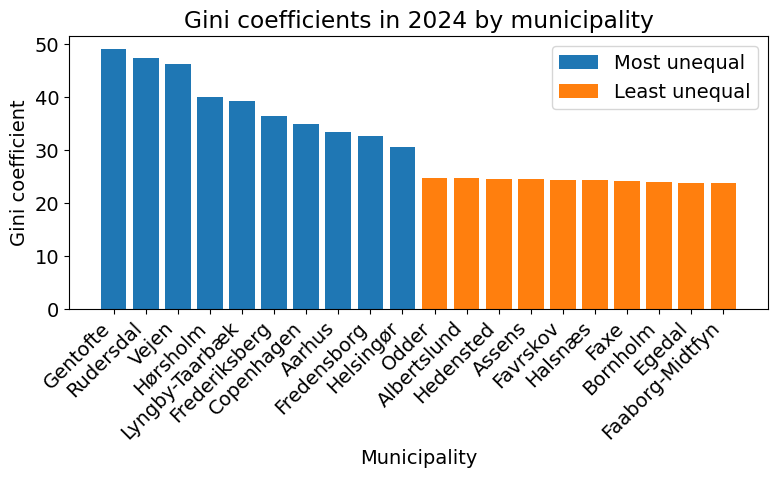

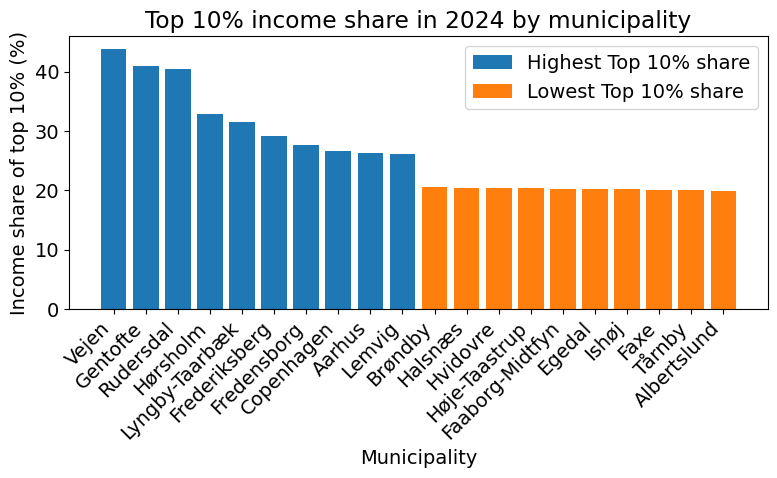

In [48]:
# Gini
plt.figure(figsize=(8,5))
plt.bar(most_unequal['KOMMUNEDK'], most_unequal['INDHOLD'], label='Most unequal')
plt.bar(least_unequal['KOMMUNEDK'], least_unequal['INDHOLD'], label='Least unequal')
plt.ylabel('Gini coefficient')
plt.xlabel('Municipality')
plt.title('Gini coefficients in 2024 by municipality')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Top 10% income share
plt.figure(figsize=(8,5))
plt.bar(most_unequal_10['KOMMUNEDK'], most_unequal_10['Top10'], label='Highest Top 10% share')
plt.bar(least_unequal_10['KOMMUNEDK'], least_unequal_10['Top10'], label='Lowest Top 10% share')
plt.ylabel('Income share of top 10% (%)')
plt.xlabel('Municipality')
plt.title('Top 10% income share in 2024 by municipality')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

We find that using either the top 10% income share or the Gini coefficient gives broadly similar results when identifying the most and least unequal municipalities. Although the ranking changes slightly, the same municipalities generally appear among the most and least unequal. 

We find that many municipalities in Northern Zealand are relatively unequal. Moreover, Vejen and Lemvig are among the most unequal municipalities. Since these are relatively small municipalities, their high inequality may be driven by a small number of individuals with very high incomes. If these individuals were excluded, these municipalities would likely no longer rank among the most unequal.

#### 1.3.3. <a id='toc1_1_'></a>[Changes in the Gini coefficient over time](#toc0_)

We calculate the change in the Gini coeffient between 1987 and 2024:

In [54]:
Gini_change = Gini_2024.merge(Gini_1987, on='KOMMUNEDK', suffixes=('_2024', '_1987'))
Gini_change['change'] = Gini_change['INDHOLD_2024'] - Gini_change['INDHOLD_1987']

display(Gini_change.nsmallest(1, 'change'))
display(Gini_change.nlargest(1, 'change'))


,KOMMUNEDK,INDHOLD_2024,INDHOLD_1987,change
61,Fanø,26.34,25.67,0.67


,KOMMUNEDK,INDHOLD_2024,INDHOLD_1987,change
63,Vejen,46.32,21.2,25.12


Plot:

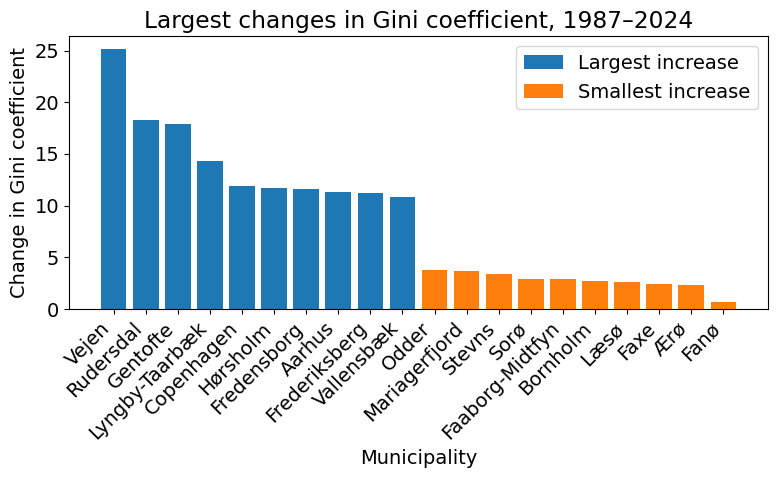

In [52]:
largest_increase = Gini_change.nlargest(10, 'change')
smallest_increase = Gini_change.nsmallest(10, 'change').iloc[::-1]

plt.figure(figsize=(8,5))
plt.bar(largest_increase['KOMMUNEDK'], largest_increase['change'], label='Largest increase')
plt.bar(smallest_increase['KOMMUNEDK'], smallest_increase['change'], label='Smallest increase')

plt.ylabel('Change in Gini coefficient')
plt.xlabel('Municipality')
plt.title('Largest changes in Gini coefficient, 1987–2024')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


Generally, the Gini coefficient has increased across all municipalities from 1987 to 2024.

We see that the Gini coefficient increased particularly sharply in Vejen, by around 25 percentage points. This suggests that the increase may be driven by a small number of individuals with very high incomes, although we cannot determine this from the Gini coefficient alone.

### 1.4. <a id='toc1_1_'></a>[Extension](#toc1_4_)

We examine the income change for the 10% of the population with the lowest incomes (the “bottom 10%”).

In [ ]:
# Calculate the bottom 10%:
Bottom10_2024 = Deciles_municipal[Deciles_municipal['TID'] == 2024].groupby('KOMMUNEDK', sort=False).apply(lambda x: x.loc[x['DECILGEN'] == 'First decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum() * 100).reset_index(name='Bund10')
Bottom10_1987 = Deciles_municipal[Deciles_municipal['TID'] == 1987].groupby('KOMMUNEDK', sort=False).apply(lambda x: x.loc[x['DECILGEN'] == 'First decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum() * 100).reset_index(name='Bund10')

# Calculate relative change between 1987 and 2024:
bottom10_change = Bottom10_2024.merge(Bottom10_1987, on='KOMMUNEDK', suffixes=('_2024', '_1987'))
bottom10_change['change'] = bottom10_change['Bund10_2024'] - bottom10_change['Bund10_1987']

We use a scatter plot to depict the correlation:

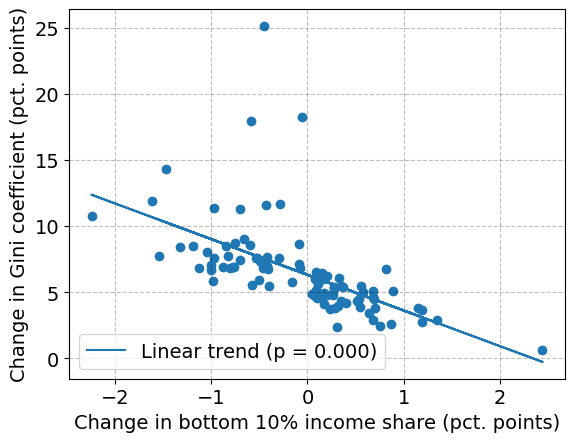

Slope: -2.6943313491724736
p-value: 4.6391348399827184e-10


In [101]:
x = bottom10_change['change']
y = Gini_change['change']

slope, intercept, r, p, se = linregress(x, y)

plt.scatter(x, y)
plt.plot(x, intercept + slope*x, label=f'Linear trend (p = {p:.3f})')
plt.xlabel('Change in bottom 10% income share (pct. points)')
plt.ylabel('Change in Gini coefficient (pct. points)')
plt.legend()
plt.show()

print('Slope:', slope)
print('p-value:', p)

As expected we find a statistically significant negative relationship between the change in the bottom 10% income share and the change in the Gini coefficient. Thus, municipalities where the bottom 10% experienced the smallest increases in income share also tended to experience the largest increases in the Gini coefficient.

## 2. <a id='toc1_'></a>[Simulating the income distribution](#toc2_)

### 2.1. <a id='toc1_1_'></a>[The model](#toc2_1_)

### 2.2. <a id='toc1_1_'></a>[Simulate the income distribution](#toc2_2_)

### 2.3. <a id='toc1_1_'></a>[Compute the Gini coefficient](#toc2_3_)

### 2.4. <a id='toc1_1_'></a>[What drives inequality?](#toc2_4_)

### 2.5. <a id='toc1_1_'></a>[Extension: more risk](#toc2_5_)